## Monday: Your First Data Point
Concept Focus: Variables, Data Types, Input/Output, Operators

Write a program that asks the user for a single PM2.5 measurement. The program will then convert this measurement from micrograms per cubic meter (mug/m3) to milligrams per cubic meter (mg/m3) and print the result.


In [1]:
# Monday: Get user input for a single PM2.5 reading
# A comment explaining our goal.

pm25_micrograms_str = input("Enter the current PM2.5 level (in µg/m³): ")

# Convert the input string to a number (float)
pm25_micrograms = float(pm25_micrograms_str)

# Convert from micrograms to milligrams using a mathematical operator
# 1000 micrograms = 1 milligram
pm25_milligrams = pm25_micrograms / 1000

# Print the result in a user-friendly format
print(f"The PM2.5 level is {pm25_milligrams} mg/m³.")

Enter the current PM2.5 level (in µg/m³): 54
The PM2.5 level is 0.054 mg/m³.


## Tuesday: Analyzing a Series of Readings
Concept Focus: Lists, Loops, Conditional Statements, Functions

Expand the script to handle a predefined list of PM2.5 readings. Create a function that classifies each reading as "Good," "Moderate," or "Unhealthy for Sensitive Groups" based on simplified EPA standards. Use a loop to process the entire list.

In [2]:
# Tuesday: Define a function to classify air quality
def classify_air_quality(pm25_value):
    """Takes a PM2.5 value and returns its quality category."""
    if 0 <= pm25_value <= 12.0:
        return "Good"
    elif 12.1 <= pm25_value <= 35.4:
        return "Moderate"
    else:
        return "Unhealthy for Sensitive Groups"

# A list of PM2.5 readings from different hours
hourly_readings = [10.5, 15.2, 36.1, 8.9, 12.1]

# Use a for loop to iterate through the list
print("Hourly Air Quality Report:")
for reading in hourly_readings:
    # Call the function for each reading in the list
    quality = classify_air_quality(reading)
    print(f"A reading of {reading} µg/m³ is considered: {quality}")

Hourly Air Quality Report:
A reading of 10.5 µg/m³ is considered: Good
A reading of 15.2 µg/m³ is considered: Moderate
A reading of 36.1 µg/m³ is considered: Unhealthy for Sensitive Groups
A reading of 8.9 µg/m³ is considered: Good
A reading of 12.1 µg/m³ is considered: Moderate


## Wednesday: Visualizing the Data
Concept Focus: Importing Packages (pandas, matplotlib)

Use the pandas library to store the hourly readings in a DataFrame and matplotlib to create a simple line plot showing how the air quality changes over time.

Air Quality Data:
   Hour  PM2.5
0     1   10.5
1     2   15.2
2     3   36.1
3     4    8.9
4     5   12.1


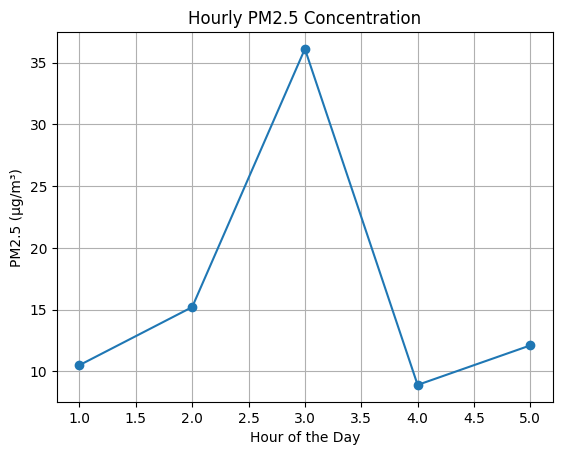

In [3]:
# Wednesday: Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt

# Data from previous day
hourly_readings = [10.5, 15.2, 36.1, 8.9, 12.1]
hours = [1, 2, 3, 4, 5]

# Create a pandas DataFrame
air_data = pd.DataFrame({
    "Hour": hours,
    "PM2.5": hourly_readings
})

print("Air Quality Data:")
print(air_data)

# Create a plot
plt.plot(air_data["Hour"], air_data["PM2.5"], marker='o')
plt.title("Hourly PM2.5 Concentration")
plt.xlabel("Hour of the Day")
plt.ylabel("PM2.5 (µg/m³)")
plt.grid(True)
plt.show()

## Thursday: Working with Real Data
Concept Focus: File Management, Data Processing

Instead of a hardcoded list, read data from a CSV file. The file will contain columns for 'Timestamp', 'Temperature_F', and 'PM2.5'. After loading the data, convert the temperature from Fahrenheit to Celsius and calculate how many readings were above the "Good" threshold.

In [7]:
# Function to convert F to C

def convert_to_celsius(fahrenheit):
    return (fahrenheit - 32) * 5/9

In [9]:
# Thursday: Read data from a CSV file
import pandas as pd

# Upload sensor_data.csv to your Colab session
df = pd.read_csv('hourly_avg.csv')

# Process data: Convert Fahrenheit to Celsius
# df['Temperature_C'] = (df['Temperature_F'] - 32) * 5/9

# Or use a function to do it:
df['Temperature_C'] = df['Temperature_F'].apply(convert_to_celsius)

# Process data: Count "Moderate" or higher readings
moderate_or_worse_count = (df['PM25'] > 12.0).sum()

print("Processed Sensor Data:")
print(df)
print(f"\nNumber of readings with PM25 > 12.0: {moderate_or_worse_count}")

Processed Sensor Data:
          Timestamp_UTC       PM25  Temperature_F  HourID  Temperature_C
0   2022-07-04 00:00:00   6.861429      82.535714       0      28.075397
1   2022-07-04 01:00:00   6.603214      81.178571       1      27.321429
2   2022-07-04 02:00:00  21.712500      80.535714       2      26.964286
3   2022-07-04 03:00:00  34.098214      79.892857       3      26.607143
4   2022-07-04 04:00:00  30.220357      79.107143       4      26.170635
5   2022-07-04 05:00:00  31.861071      78.750000       5      25.972222
6   2022-07-04 06:00:00  27.861429      79.035714       6      26.130952
7   2022-07-04 07:00:00  25.905000      78.678571       7      25.932540
8   2022-07-04 08:00:00  17.143214      77.250000       8      25.138889
9   2022-07-04 09:00:00  16.097037      76.259259       9      24.588477
10  2022-07-04 10:00:00  15.884286      75.821429      10      24.345238
11  2022-07-04 11:00:00  17.555357      76.535714      11      24.742063
12  2022-07-04 12:00:00  20.

### Friday: Calculating the AQI
**Concept Focus:** Combining all concepts to calculate a simplified AQI

Write a final function that calculates the Air Quality Index (AQI) for a given PM2.5 value. Apply this function to your DataFrame to create a new 'AQI' column. The AQI formula is a bit complex, but we'll use a simplified version for the "Good" and "Moderate" ranges.

**AQI Formula:**
$$AQI = \frac{I_{high} - I_{low}}{BP_{high} - BP_{low}} (C_p - BP_{low}) + I_{low}$$

**Variable Definitions:**

* **$C_p$** = The concentration of the pollutant (in our case, your measured PM2.5 value in µg/m³).
* **$BP_{high}$** = The PM2.5 concentration breakpoint that is *greater than or equal to* $C_p$.
* **$BP_{low}$** = The PM2.5 concentration breakpoint that is *less than or equal to* $C_p$.
* **$I_{high}$** = The AQI value corresponding to $BP_{high}$.
* **$I_{low}$** = The AQI value corresponding to $BP_{low}$.

In [13]:
# Friday: Calculate the AQI
import pandas as pd

def calculate_aqi(pm25):
    """Calculates a simplified AQI for a PM2.5 value."""
    if 0 <= pm25 <= 12.0:
        # AQI for "Good" range (0-50)
        # BPhigh=12.0, BPlow=0, Ihigh=50, Ilow=0
        return round((50 - 0) / (12.0 - 0) * (pm25 - 0) + 0)
    elif 12.1 <= pm25 <= 35.4:
        # AQI for "Moderate" range (51-100)
        # BPhigh=35.4, BPlow=12.1, Ihigh=100, Ilow=51
        return round((100 - 51) / (35.4 - 12.1) * (pm25 - 12.1) + 51)
    # Add more elif statements for other categories as an extension
    else:
        return 101 # For anything above moderate for this example

# Use the DataFrame from Day 4
df = pd.read_csv('hourly_avg.csv')
df['Temperature_C']=df['Temperature_F'].apply(convert_to_celsius)

# Apply the function to the 'PM2.5' column to create a new 'AQI' column
df['AQI'] = df['PM25'].apply(calculate_aqi)

print("Final Air Quality Report with AQI:")
print(df)

Final Air Quality Report with AQI:
          Timestamp_UTC       PM25  Temperature_F  HourID  Temperature_C  AQI
0   2022-07-04 00:00:00   6.861429      82.535714       0      28.075397   29
1   2022-07-04 01:00:00   6.603214      81.178571       1      27.321429   28
2   2022-07-04 02:00:00  21.712500      80.535714       2      26.964286   71
3   2022-07-04 03:00:00  34.098214      79.892857       3      26.607143   97
4   2022-07-04 04:00:00  30.220357      79.107143       4      26.170635   89
5   2022-07-04 05:00:00  31.861071      78.750000       5      25.972222   93
6   2022-07-04 06:00:00  27.861429      79.035714       6      26.130952   84
7   2022-07-04 07:00:00  25.905000      78.678571       7      25.932540   80
8   2022-07-04 08:00:00  17.143214      77.250000       8      25.138889   62
9   2022-07-04 09:00:00  16.097037      76.259259       9      24.588477   59
10  2022-07-04 10:00:00  15.884286      75.821429      10      24.345238   59
11  2022-07-04 11:00:00  17.5

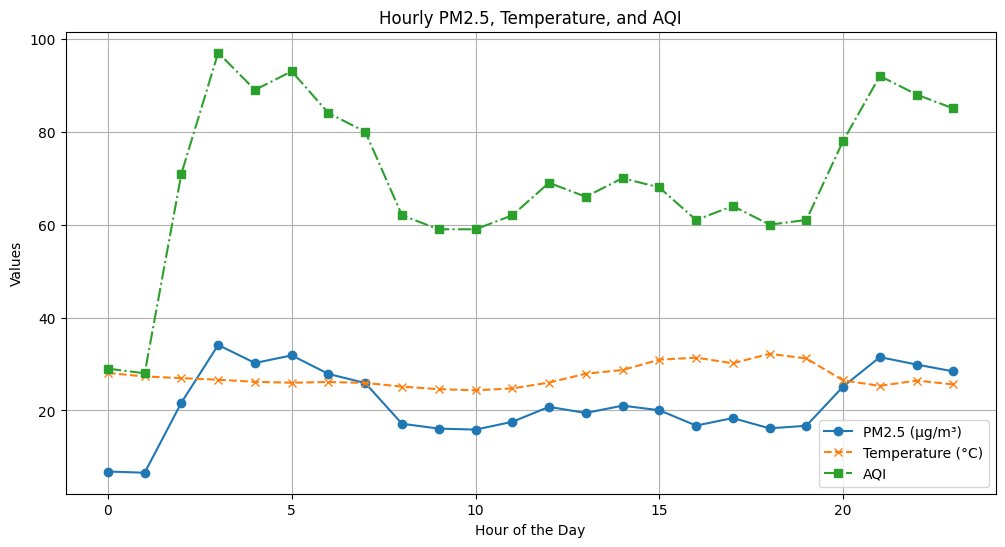

In [14]:
# Plot the PM25, Temp and AQI vs hour plot

import matplotlib.pyplot as plt

# Plotting PM2.5, Temperature_C, and AQI vs HourID
plt.figure(figsize=(12, 6)) # Adjust figure size as needed

plt.plot(df['HourID'], df['PM25'], marker='o', linestyle='-', label='PM2.5 (µg/m³)')
plt.plot(df['HourID'], df['Temperature_C'], marker='x', linestyle='--', label='Temperature (°C)')
plt.plot(df['HourID'], df['AQI'], marker='s', linestyle='-.', label='AQI')

plt.title("Hourly PM2.5, Temperature, and AQI")
plt.xlabel("Hour of the Day")
plt.ylabel("Values")
plt.legend()
plt.grid(True)
plt.show()

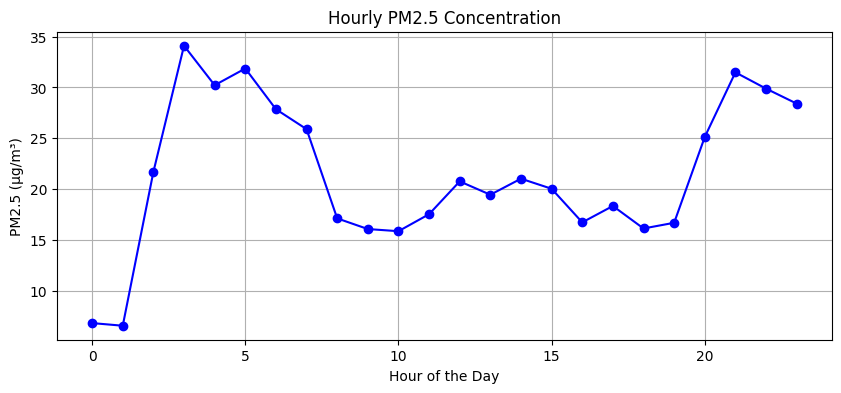

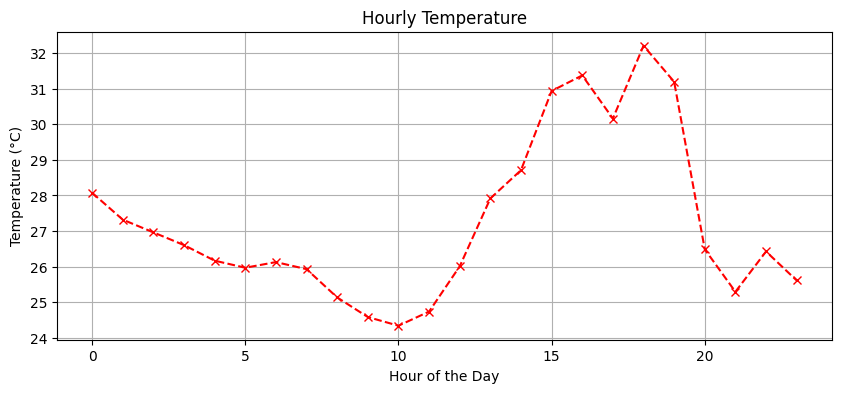

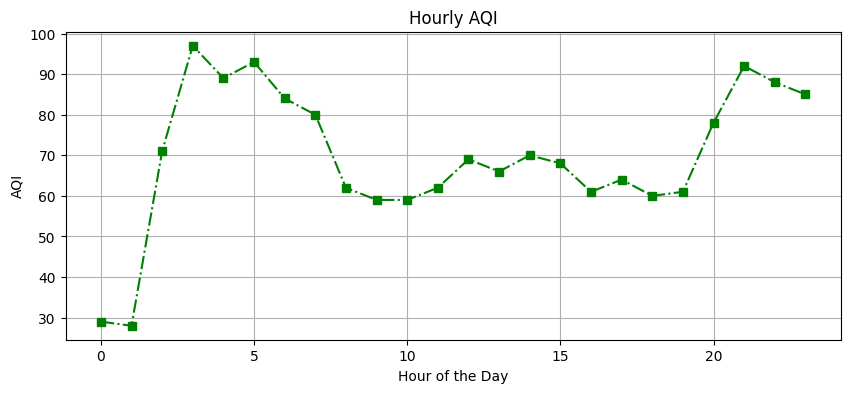

In [16]:
# show these in seprate plots:

import matplotlib.pyplot as plt

# Plotting PM2.5 vs HourID
plt.figure(figsize=(10, 4))
plt.plot(df['HourID'], df['PM25'], marker='o', linestyle='-', color='blue')
plt.title("Hourly PM2.5 Concentration")
plt.xlabel("Hour of the Day")
plt.ylabel("PM2.5 (µg/m³)")
plt.grid(True)
plt.show()

# Plotting Temperature_C vs HourID
plt.figure(figsize=(10, 4))
plt.plot(df['HourID'], df['Temperature_C'], marker='x', linestyle='--', color='red')
plt.title("Hourly Temperature")
plt.xlabel("Hour of the Day")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

# Plotting AQI vs HourID
plt.figure(figsize=(10, 4))
plt.plot(df['HourID'], df['AQI'], marker='s', linestyle='-.', color='green')
plt.title("Hourly AQI")
plt.xlabel("Hour of the Day")
plt.ylabel("AQI")
plt.grid(True)
plt.show()